In [1]:
#importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

Load Data set

In [2]:
df = pd.read_csv("ev_charging_data.csv", parse_dates=["datetime"])

Data Inspection

In [3]:
df.head()


,session_id,datetime,hour,day_of_week,is_weekend,temperature,wholesale_price,retail_price,charging_sessions,energy_per_session,energy_sold_kwh
0,1,2025-01-01 00:00:00,0,2,0,25.127134,0.188319,0.235398,5,13.923257,69.616286
1,2,2025-01-01 01:00:00,1,2,0,25.190453,0.182241,0.227801,3,25.697249,77.091747
2,3,2025-01-01 02:00:00,2,2,0,27.573437,0.206828,0.258534,1,25.714565,25.714565
3,4,2025-01-01 03:00:00,3,2,0,28.977748,0.198582,0.248228,2,20.320314,40.640627
4,5,2025-01-01 04:00:00,4,2,0,28.294179,0.208094,0.260118,2,24.234807,48.469613


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2880 entries, 0 to 2879
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   session_id          2880 non-null   int64         
 1   datetime            2880 non-null   datetime64[ns]
 2   hour                2880 non-null   int64         
 3   day_of_week         2880 non-null   int64         
 4   is_weekend          2880 non-null   int64         
 5   temperature         2880 non-null   float64       
 6   wholesale_price     2880 non-null   float64       
 7   retail_price        2880 non-null   float64       
 8   charging_sessions   2880 non-null   int64         
 9   energy_per_session  2880 non-null   float64       
 10  energy_sold_kwh     2880 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(5)
memory usage: 247.6 KB


In [5]:
df.describe()

,session_id,datetime,hour,day_of_week,is_weekend,temperature,wholesale_price,retail_price,charging_sessions,energy_per_session,energy_sold_kwh
count,2880.000000,2880,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000
mean,1440.500000,2025-03-01 23:30:00,11.500000,2.991667,0.283333,25.024653,0.150080,0.187600,5.751736,21.944694,124.771842
min,1.000000,2025-01-01 00:00:00,0.000000,0.000000,0.000000,17.540839,0.073516,0.091896,0.000000,11.109137,0.000000
25%,720.750000,2025-01-30 23:45:00,5.750000,1.000000,0.000000,21.647244,0.116725,0.145906,3.000000,19.882307,74.544935
50%,1440.500000,2025-03-01 23:30:00,11.500000,3.000000,0.000000,24.938122,0.150469,0.188087,6.000000,21.866043,119.764736
75%,2160.250000,2025-03-31 23:15:00,17.250000,5.000000,1.000000,28.432234,0.183916,0.229895,8.000000,24.146358,171.757197
max,2880.000000,2025-04-30 23:00:00,23.000000,6.000000,1.000000,32.459616,0.228819,0.286024,15.000000,33.014953,383.230396
std,831.528713,NaN,6.923389,1.994069,0.450695,3.671151,0.036790,0.045987,2.990984,3.188625,65.700812


In [6]:
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 session_id            0
datetime              0
hour                  0
day_of_week           0
is_weekend            0
temperature           0
wholesale_price       0
retail_price          0
charging_sessions     0
energy_per_session    0
energy_sold_kwh       0
dtype: int64


Demand Distribution

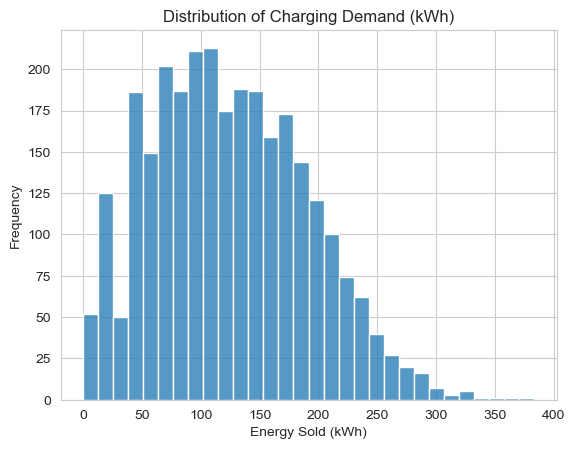

In [7]:
plt.figure()
sns.histplot(df["energy_sold_kwh"], bins=30)
plt.title("Distribution of Charging Demand (kWh)")
plt.xlabel("Energy Sold (kWh)")
plt.ylabel("Frequency")
plt.show()

the histogram is slightly right-skewed. This show that the simulated data properly immitate real world trend, and we can deduce that high-demand hours create revenue concentration opportunities.  
**Charging demand follows a relatively stable distribution with moderate peak clustering, suggesting the feasibility of regression-based demand modeling.**

Hourly Demand Pattern

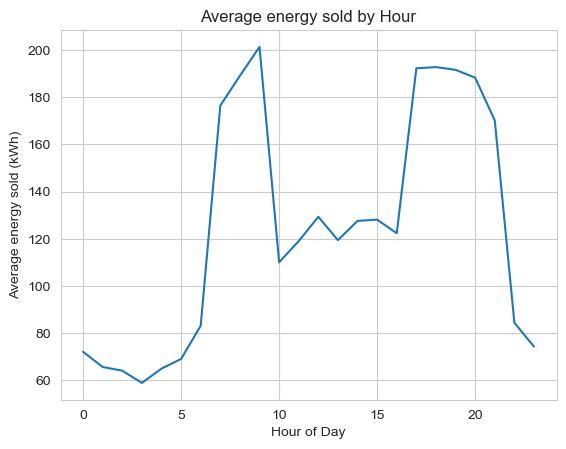

In [8]:
hourly_avg = df.groupby("hour")["energy_sold_kwh"].mean()

plt.figure()
hourly_avg.plot()
plt.title("Average energy sold by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average energy sold (kWh)")
plt.show()

From the line plot, we can see that demand falls in the early hours (0 - 5)am, then rise once the day break, drops at from (9 - 10) most people are at work by this time, rises steadily from (10am - 4pm), then sharply after 4pm, then peaks between (5-8)pm showing the rush hour when most people close from work, before it drops. This pattern rightly immitate the real world trend.  

**Demand exhibits strong diurnal seasonality with pronounced peaks during commuting hours (7–9 AM and 5–9 PM), indicating significant pricing leverage during high-demand windows.**

Weekend vs Weekdays demand

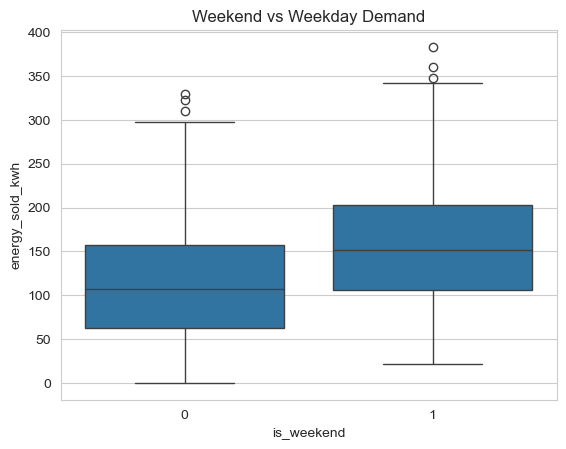

In [9]:
sns.boxplot(x="is_weekend", y="energy_sold_kwh", data=df)
plt.title("Weekend vs Weekday Demand")
plt.show()

we can see here that there is a higher variance in the weekends demand, and a higher median demand too.  
**Weekend demand demonstrates distinct behavioral patterns compared to weekdays, suggesting that pricing models should incorporate calendar-based segmentation.**

Temperature vs Demand

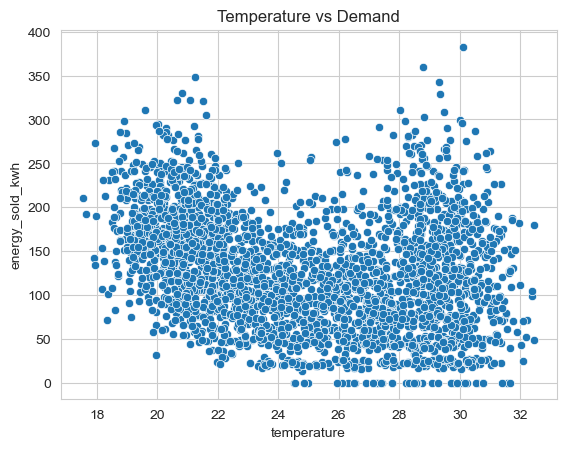

In [10]:
plt.figure()
sns.scatterplot(x="temperature", y="energy_sold_kwh", data=df)
plt.title("Temperature vs Demand")
plt.show()

Temperature shows a moderate positive correlation with charging demand, supporting its inclusion as a predictive feature in the demand model.

retail Price vs Demand

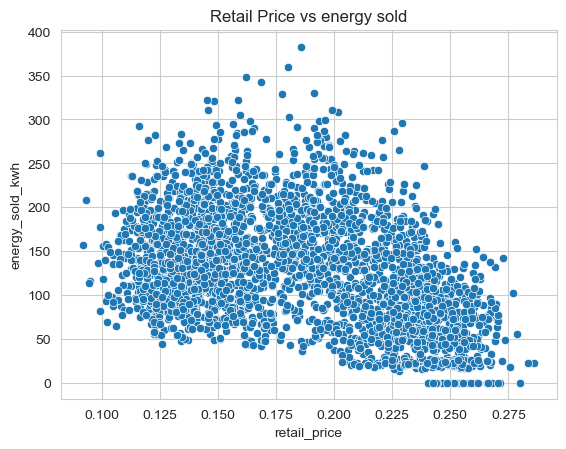

In [11]:
plt.figure()
sns.scatterplot(x="retail_price", y="energy_sold_kwh", data=df)
plt.title("Retail Price vs energy sold")
plt.show()

as the retail price increases the demand decreases.  
This Justifies demand function: **D = a - bP**  

Demand demonstrates inverse sensitivity to retail electricity price, confirming the presence of price elasticity and validating the linear demand assumption used in the optimization framework.

Charging session vs demand

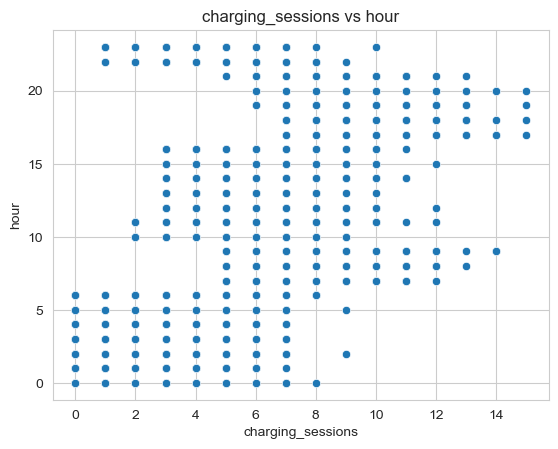

In [12]:
plt.figure()
sns.scatterplot(x="charging_sessions", y="hour", data=df)
plt.title("charging_sessions vs hour")
plt.show()

There are more charge sessions during rush hours

Static price simulation

In [13]:
df["static_retail_price"] = df["wholesale_price"].mean() * 1.25
df["static_revenue"] = df["static_retail_price"] * df["energy_sold_kwh"]
df["static_cost"] = df["energy_sold_kwh"] * df["wholesale_price"]
df["static_profit"] = df["static_revenue"] - df["static_cost"]

print(f"static_profit : {df['static_profit'].sum()}")

static_profit : 16623.202908823037


Revenue concentration

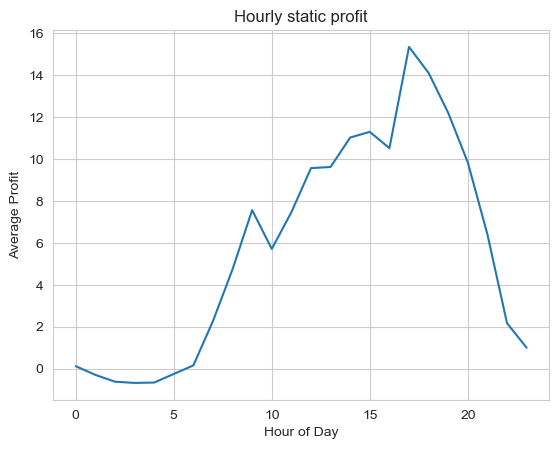

In [14]:
hourly_avg = df.groupby("hour")["static_profit"].mean()

plt.figure()
hourly_avg.plot()
plt.title("Hourly static profit")
plt.xlabel("Hour of Day")
plt.ylabel("Average Profit")
plt.show()

Profit concentration is heavily skewed toward peak demand windows, suggesting an opportunity for strategic price differentiation.

Margin Inefficiency

In [15]:
df["static_margin"] = (
    df["static_retail_price"] - df["wholesale_price"]
) / df["static_retail_price"]

print("Static margin:", round(df["static_margin"].mean(),2))

Static margin: 0.2


The static pricing strategy produces a fixed 20% gross margin, regardless of demand conditions. Because demand varies significantly by hour, a uniform margin fails to capture additional consumer willingness to pay during peak charging periods.

With static pricing the profit margin is constant, and the demand is variable, but with the dynamic pricing, the margin is adjustable, and demand is optimized which leads to profit maximization.

Peak Hour Underpricing

In [16]:
peak_hours = (df["hour"].between(7, 9)) | (df["hour"].between(17, 21))
peak_df = df[peak_hours]
avg_energy_sold_peak = peak_df["energy_sold_kwh"].mean()
avg_static_price_peak = peak_df["static_retail_price"].mean()

print(f"Average Total Demand during Peak Hours: {avg_energy_sold_peak:.2f} kWh")
print(f"Average Static Retail Price during Peak Hours: ${avg_static_price_peak:.4f}")

hourly_peak = peak_df.groupby("hour")[["energy_sold_kwh", "static_retail_price"]].mean().reset_index()

print("\nHourly Average energy sold and Static Price during Peak Hours:")
print(hourly_peak)


Average Total Demand during Peak Hours: 187.73 kWh
Average Static Retail Price during Peak Hours: $0.1876

Hourly Average energy sold and Static Price during Peak Hours:
   hour  energy_sold_kwh  static_retail_price
0     7       176.441910               0.1876
1     8       189.076405               0.1876
2     9       201.301588               0.1876
3    17       192.256365               0.1876
4    18       192.754930               0.1876
5    19       191.586671               0.1876
6    20       188.274076               0.1876
7    21       170.147896               0.1876


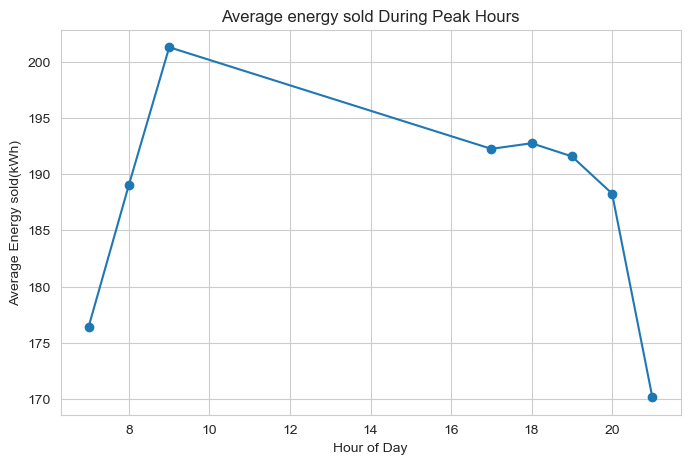

In [17]:
# Peak Hour Demand Pattern
plt.figure(figsize=(8,5))
plt.plot(hourly_peak["hour"], hourly_peak["energy_sold_kwh"], marker="o")
plt.title("Average energy sold During Peak Hours")
plt.xlabel("Hour of Day")
plt.ylabel("Average Energy sold(kWh)")
plt.grid(True)
plt.show()



The plot shows two clear peaks: morning commuting hours (7–9 AM) and evening residential charging (5–9 PM). Evening demand is typically higher due to longer charging sessions after daily travel.

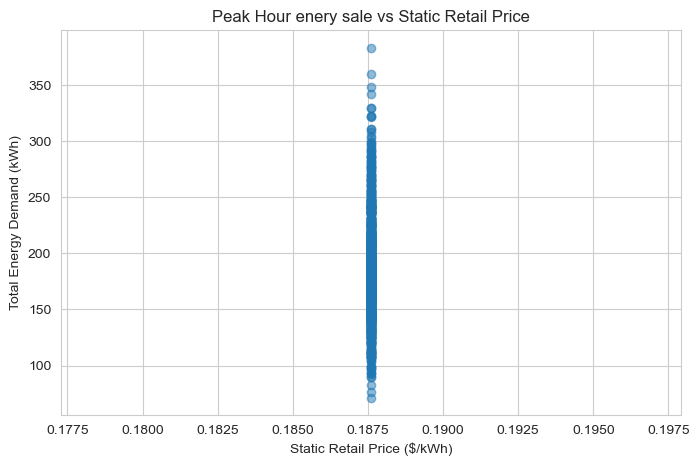

In [18]:
# Energy sold vs Static Retail Price
plt.figure(figsize=(8,5))
plt.scatter(peak_df["static_retail_price"], peak_df["energy_sold_kwh"], alpha=0.5)
plt.title("Peak Hour enery sale vs Static Retail Price")
plt.xlabel("Static Retail Price ($/kWh)")
plt.ylabel("Total Energy Demand (kWh)")
plt.grid(True)
plt.show()

Under a static pricing strategy, electricity prices remain constant regardless of demand spikes. This results in missed revenue opportunities during high-demand hours when customers exhibit low price sensitivity.